## Representative EEG and EMG signals for mice of the eai, tcspi, narco and syn groups

Opening raw data file /home/darryld/documents/EEG/preprocessed/XAI/data/RJ42/RJ42_raw.fif...
Isotrak not found
Isotrak not found
    Range : 0 ... 9000191 =      0.000 ... 35156.996 secs
Ready.
    Range : 0 ... 9000191 =      0.000 ... 35156.996 secs
Ready.
Reading 0 ... 9000191  =      0.000 ... 35156.996 secs...
Reading 0 ... 9000191  =      0.000 ... 35156.996 secs...
Opening raw data file /home/darryld/documents/EEG/preprocessed/XAI/data/MC154/MC154_raw.fif...
Opening raw data file /home/darryld/documents/EEG/preprocessed/XAI/data/MC154/MC154_raw.fif...
Isotrak not found
    Range : 0 ... 7656191 =      0.000 ... 29906.996 secs
Ready.
Isotrak not found
    Range : 0 ... 7656191 =      0.000 ... 29906.996 secs
Ready.
Reading 0 ... 7656191  =      0.000 ... 29906.996 secs...
Reading 0 ... 7656191  =      0.000 ... 29906.996 secs...
Opening raw data file /home/darryld/documents/EEG/preprocessed/XAI/data/CJL159/CJL159_raw.fif...
Opening raw data file /home/darryld/documents/EEG/prepro

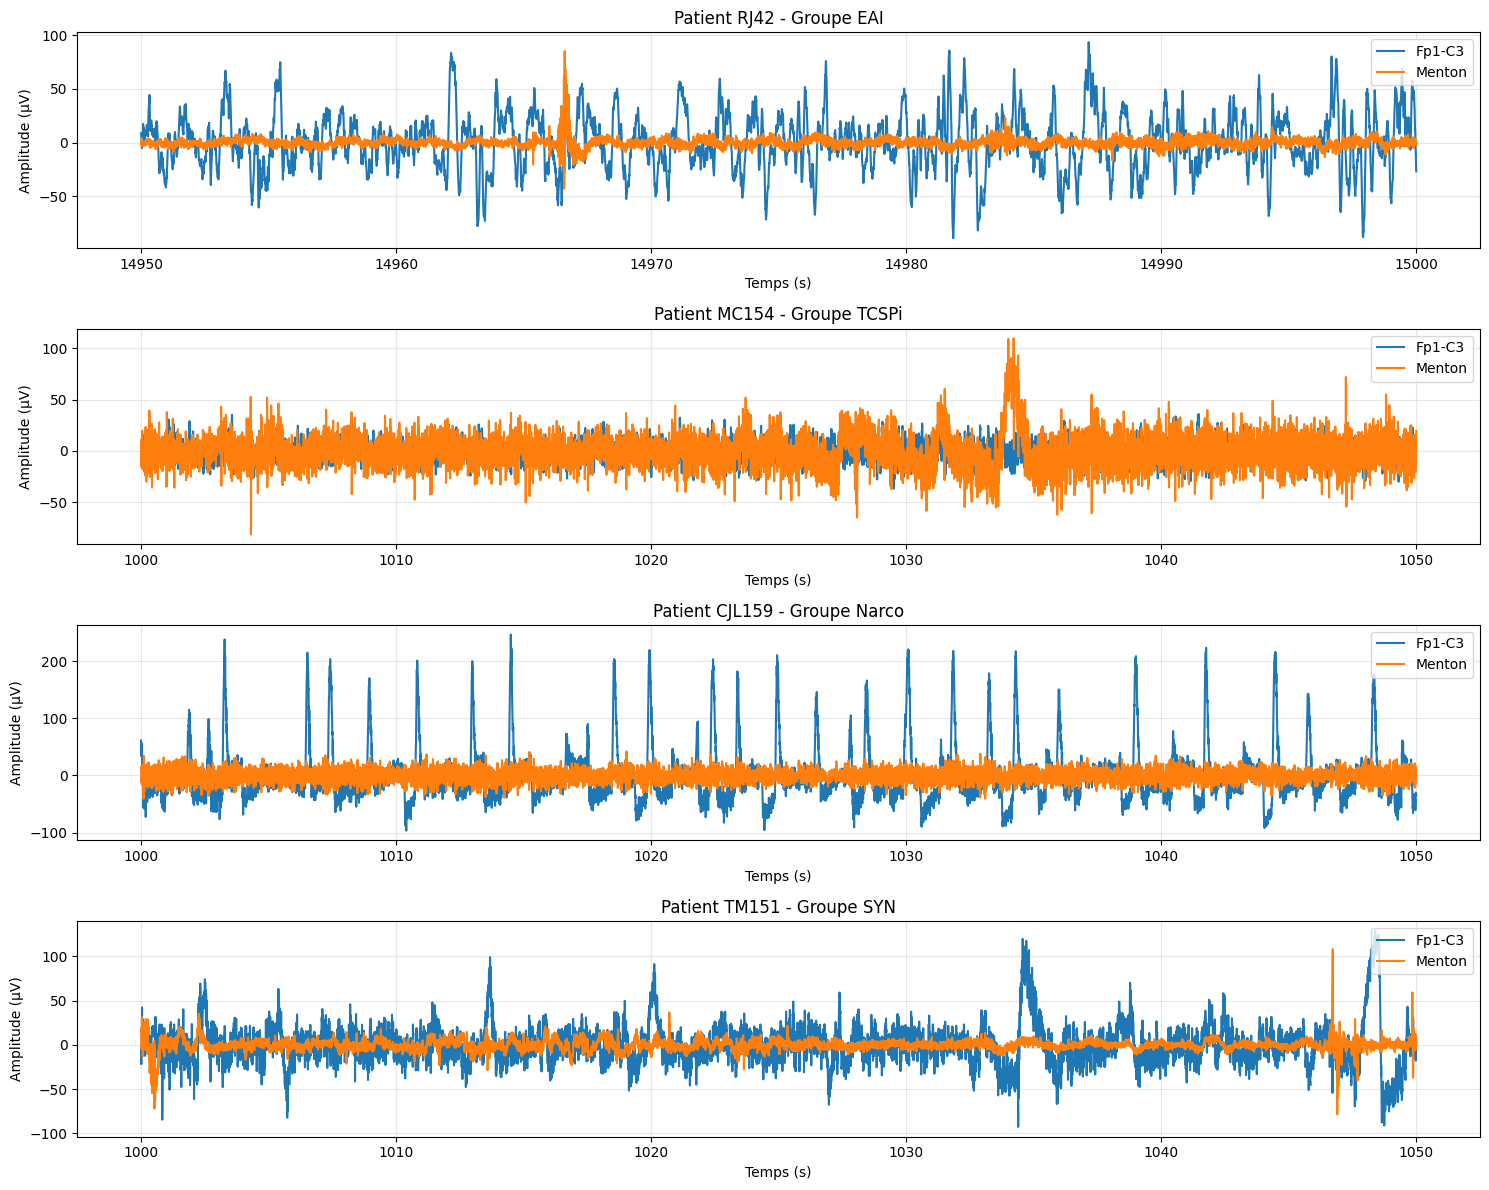

In [28]:
# Affichage de 4 patients représentatifs (un par groupe)

import sys
from pathlib import Path
ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT))
import mne
import matplotlib.pyplot as plt
from src.data.preprocessing import apply_montage_gp2

# Configuration des 4 patients avec leurs paramètres de visualisation
patients_config = [
    {"id": "RJ42", "group": "EAI", "start": 14950, "duration": 50}, # NARCO
    {"id": "MC154", "group": "TCSPi", "start": 1000, "duration": 50},  # TCSPi
    {"id": "CJL159", "group": "Narco", "start": 1000, "duration": 50},  # EAI
    {"id": "TM151", "group": "SYN", "start": 1000, "duration": 50},    # SYN
]

# Canaux à afficher
picks = ['Fp1-C3', 'Menton']
scalings = 100e-6  # Échelle d'affichage

# Créer une figure avec 4 sous-graphiques
fig, axes = plt.subplots(4, 1, figsize=(15, 12))

for idx, config in enumerate(patients_config):
    patient_id = config["id"]
    group = config["group"]
    start_time = config["start"]
    duration = config["duration"]
    
    file_path = Path(f"/home/darryld/documents/EEG/preprocessed/XAI/data/{patient_id}/{patient_id}_raw.fif")
    
    if file_path.exists():
        raw = mne.io.read_raw_fif(file_path, preload=True)
        
        # Extraire les données pour les canaux sélectionnés
        data, times = raw.get_data(picks=picks, start=int(start_time * raw.info['sfreq']), 
                                     stop=int((start_time + duration) * raw.info['sfreq']), 
                                     return_times=True)
        
        # Affichage sur le sous-graphique correspondant
        ax = axes[idx]
        for ch_idx, ch_name in enumerate(picks):
            ax.plot(times, data[ch_idx] * 1e6, label=ch_name)  # Conversion en µV
        
        ax.set_title(f"Patient {patient_id} - Groupe {group}")
        ax.set_xlabel("Temps (s)")
        ax.set_ylabel("Amplitude (µV)")
        ax.legend(loc='upper right')
        ax.grid(True, alpha=0.3)
    else:
        print(f"Fichier non trouvé pour {patient_id}: {file_path}")

plt.tight_layout()
plt.show()

In [35]:
# Chargement csv
import pandas as pd
import numpy as np

csv_path = "/home/darryld/Cerco_studies/data/rbd_emg_events_and_summary_4s_per_channel.csv"
labels_path = "/home/darryld/Cerco_studies/data/patients_label.txt"

# Charger CSV
df = pd.read_csv(csv_path)

# Charger labels
labels = pd.read_csv(labels_path, header=None, names=["patient_id", "group"])
labels["patient_id"] = labels["patient_id"].str.strip()
labels["group"] = labels["group"].str.strip()

# Fusion
df = df.merge(labels, on="patient_id", how="left")

print("Groupes :", df["group"].unique())
print("Canaux :", df["channel"].unique())
df.head()




Groupes : ['TCSP' 'NARCO' 'SYN' 'EAI']
Canaux : ['Menton' 'JAMBD' 'JAMBG' 'EMG1' 'EMG2']


,patient_id,channel,type,episode_index,epoch_index,epoch_len_sec,epoch_start_sec,epoch_end_sec,phasic_time_sec,phasic_ratio,very_phasic,tonic_ratio,tonic_excluded,rswa,phasic_count,start_sec,end_sec,duration_sec,group
0,CM161,Menton,REM_EPOCH_4S,0,0.0,4.0,26792.0,26796.0,0.0,0.0,False,1.139556,False,False,0.0,NaN,NaN,NaN,TCSP
1,CM161,Menton,REM_EPOCH_4S,0,1.0,4.0,26796.0,26800.0,0.0,0.0,False,1.155613,False,False,0.0,NaN,NaN,NaN,TCSP
2,CM161,Menton,REM_EPOCH_4S,0,2.0,4.0,26800.0,26804.0,0.0,0.0,False,0.399202,False,False,0.0,NaN,NaN,NaN,TCSP
3,CM161,Menton,REM_EPOCH_4S,0,3.0,4.0,26804.0,26808.0,0.0,0.0,False,3.460422,False,True,0.0,NaN,NaN,NaN,TCSP
4,CM161,Menton,REM_EPOCH_4S,0,4.0,4.0,26808.0,26812.0,0.0,0.0,False,2.879606,False,True,0.0,NaN,NaN,NaN,TCSP


In [36]:
# Patients non-labélisés 

df[df["group"].isna()]["patient_id"].unique()

array([], dtype=object)

In [38]:
# -------------------------------------------------------------
# 0) Paramètre essentiel
# -------------------------------------------------------------
epoch_len = df["epoch_len_sec"].dropna().iloc[0]


# -------------------------------------------------------------
# 1) PHASIC METRICS — Niveau patient × group × channel
# -------------------------------------------------------------

# % REM avec ≥1 phasic (par patient)
phasic_ep_patient = (
    df[df["type"] == "REM_EPOCH_4S"]
    .groupby(["patient_id", "group", "channel", "episode_index"])
    .agg(has_phasic=("phasic_count", lambda x: (x > 0).any()))
    .reset_index()
)

phasic_summary = (
    phasic_ep_patient
    .groupby(["patient_id", "group", "channel"])
    .agg(pct_ep_with_phasic=("has_phasic", "mean"))
    .reset_index()
)


# densité phasique (nb/min)
phasic_density_patient = (
    df[df["type"] == "REM_EPOCH_4S"]
    .groupby(["patient_id","group","channel","episode_index"])
    .agg(
        phasic_count_total=("phasic_count","sum"),
        n_epochs=("epoch_len_sec","count")
    )
    .assign(total_rem_s=lambda x: x.n_epochs * epoch_len)
    .assign(phasic_density=lambda x: 60 * x.phasic_count_total / x.total_rem_s)
    .groupby(["patient_id","group","channel"])
    .agg(mean_phasic_density=("phasic_density","mean"))
    .reset_index()
)


# % du temps REM en phasic
phasic_time_patient = (
    df[df["type"] == "REM_EPOCH_4S"]
    .groupby(["patient_id","group","channel","episode_index"])
    .agg(
        phasic_time_s=("phasic_time_sec", "sum"),
        total_time_s=("epoch_len_sec", lambda x: len(x) * epoch_len)
    )
    .assign(mean_perc_phasic=lambda x: x.phasic_time_s / x.total_time_s)
    .groupby(["patient_id","group","channel"])
    .agg(mean_perc_phasic=("mean_perc_phasic","mean"))
    .reset_index()
)


# % d’épisodes très phasiques >75%
phasic_heavy_patient = (
    df[df["type"] == "REM_EPOCH_4S"]
    .assign(is_heavy=lambda x: x["phasic_ratio"] > 0.75)
    .groupby(["patient_id","group","channel","episode_index"])
    .agg(ep_heavy=("is_heavy", "any"))
    .groupby(["patient_id","group","channel"])
    .agg(pct_heavy=("ep_heavy","mean"))
    .reset_index()
)


# -------------------------------------------------------------
# 2) TONIC METRICS
# -------------------------------------------------------------

# tonic REM/NREM ratio (médian par patient × channel)
tonic_patient = (
    df[df["type"] == "REM_EPOCH_4S"]
    .groupby(["patient_id","group","channel","episode_index"])
    .agg(median_epoch_tonic=("tonic_ratio","median"))
    .groupby(["patient_id","group","channel"])
    .agg(median_tonic_ratio=("median_epoch_tonic","median"))
    .reset_index()
)


# % RSWA (tonic_ratio > 1.3)
rswa_patient = (
    df[df["type"] == "REM_EPOCH_4S"]
    .assign(is_rswa=lambda x: x["tonic_ratio"] > 1.3)
    .groupby(["patient_id","group","channel","episode_index"])
    .agg(rswa=("is_rswa","any"))
    .groupby(["patient_id","group","channel"])
    .agg(pct_rswa=("rswa","mean"))
    .reset_index()
)


# -------------------------------------------------------------
# 3) FUSION — Maintenant possible grâce à patient_id
# -------------------------------------------------------------
summary_patient = (
    phasic_summary
    .merge(phasic_density_patient, on=["patient_id","group","channel"], how="left")
    .merge(phasic_time_patient, on=["patient_id","group","channel"], how="left")
    .merge(phasic_heavy_patient, on=["patient_id","group","channel"], how="left")
    .merge(tonic_patient, on=["patient_id","group","channel"], how="left")
    .merge(rswa_patient, on=["patient_id","group","channel"], how="left")
)

summary_patient


,patient_id,group,channel,pct_ep_with_phasic,mean_phasic_density,mean_perc_phasic,pct_heavy,median_tonic_ratio,pct_rswa
0,AE129,NARCO,EMG1,0.617021,1.734275,0.076079,0.531915,0.934026,0.893617
1,AE129,NARCO,EMG2,0.553191,1.839553,0.087079,0.489362,1.001523,0.893617
2,AE129,NARCO,JAMBD,0.617021,2.300186,0.109888,0.553191,1.017785,0.851064
3,AE129,NARCO,JAMBG,0.595745,2.602546,0.131585,0.531915,0.995475,0.787234
4,AE129,NARCO,Menton,0.468085,1.640826,0.081118,0.425532,0.582879,0.787234
...,...,...,...,...,...,...,...,...,...
283,VJ149,TCSP,EMG1,0.526316,1.960528,0.079169,0.315789,0.993224,0.789474
284,VJ149,TCSP,EMG2,0.368421,1.994916,0.088677,0.315789,0.954222,0.947368
285,VJ149,TCSP,JAMBD,0.263158,0.698671,0.032369,0.210526,1.003184,0.368421
286,VJ149,TCSP,JAMBG,0.315789,0.921648,0.042941,0.157895,0.992005,0.526316


In [58]:
def plot_metric_by_channel(summary_patient, channel_name, metric_col, ylabel, title):
    # Filtrer pour le canal
    data_ch = summary_patient[summary_patient["channel"] == channel_name].copy()
    
    # ----------------------------------------
    #  Filtrage IQR des outliers (par group)
    # ----------------------------------------
    filtered = []
    for group_name, df_group in data_ch.groupby("group"):
        Q1 = df_group[metric_col].quantile(0.25)
        Q3 = df_group[metric_col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        
        df_filt = df_group[(df_group[metric_col] >= lower) & 
                           (df_group[metric_col] <= upper)]
        filtered.append(df_filt)

    data_filt = pd.concat(filtered, ignore_index=True)

    # ----------------------------------------
    #  FIGURE
    # ----------------------------------------
    plt.figure(figsize=(7,6))

    # Boxplot sans outliers
    sns.boxplot(
        data=data_filt,
        x="group",
        y=metric_col,
        hue="group",
        palette=palette,
        showfliers=False,
        legend=False
    )

    # Points individuels
    sns.stripplot(
        data=data_filt,
        x="group",
        y=metric_col,
        hue="group",
        dodge=True,
        color="black",
        alpha=0.6,
        legend=False
    )

    plt.title(f"{title}\nCanal : {channel_name}", fontsize=20)
    plt.xlabel("")
    plt.ylabel(ylabel)

    # Ajustement automatique de l'axe Y
    ymin, ymax = data_filt[metric_col].min(), data_filt[metric_col].max()
    yrange = ymax - ymin
    plt.ylim(ymin - 0.05*yrange, ymax + 0.05*yrange)

    plt.tight_layout()
    plt.show()


## Visualisation

In [59]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid", context="talk")

# Palette harmonisée (4 groupes)
palette = {
    "NARCO": "#F15854",
    "SYN":   "#44AA99",
    "EAI":   "#C9D175",
    "TCSP":  "#BEBEBE"
}


## Figure 1 ) % de période REM avec au moins un phasic event 

/tmp/ipykernel_220867/3682984918.py:39: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(


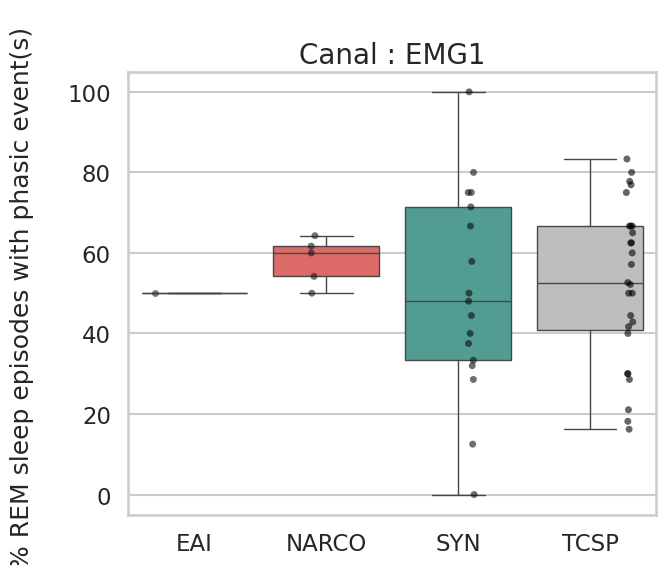

/tmp/ipykernel_220867/3682984918.py:39: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(


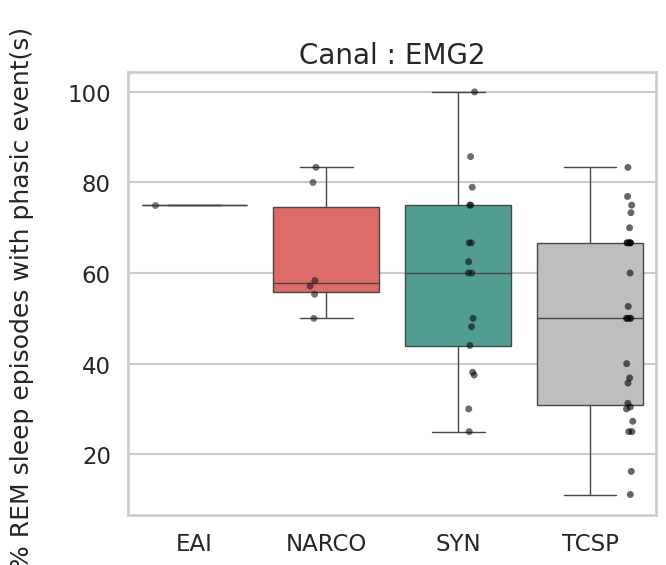

/tmp/ipykernel_220867/3682984918.py:39: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(


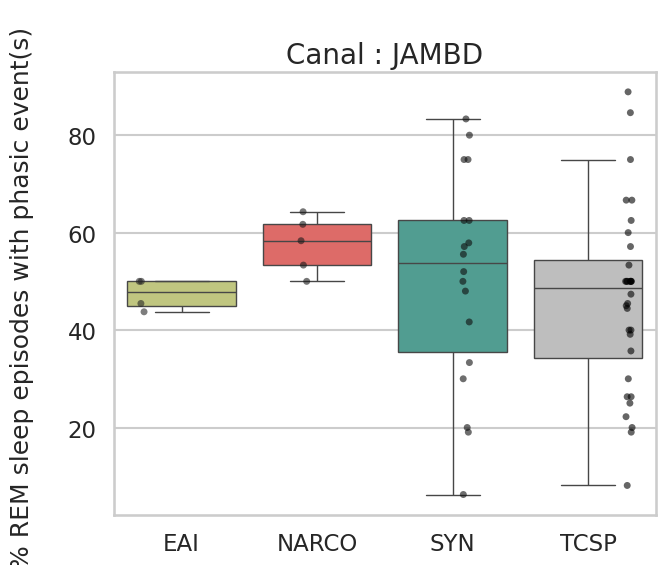

/tmp/ipykernel_220867/3682984918.py:39: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(


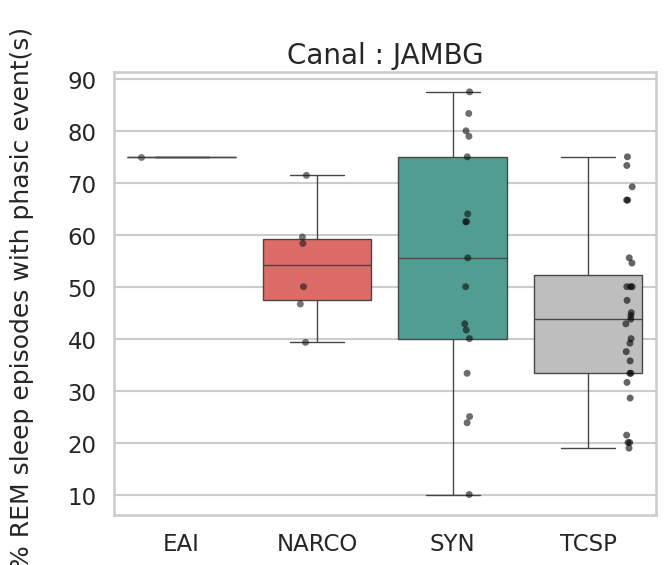

/tmp/ipykernel_220867/3682984918.py:39: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(


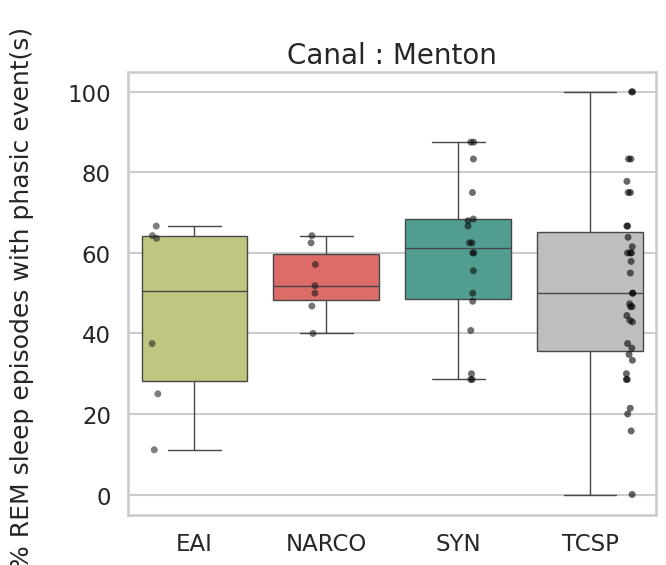

In [81]:
df_plot = summary_patient.copy()
df_plot["pct_ep_with_phasic"] = df_plot["pct_ep_with_phasic"] * 100

for ch in df_plot["channel"].unique():
    plot_metric_by_channel(
        df_plot,
        channel_name=ch,
        metric_col="pct_ep_with_phasic",
        ylabel="% REM sleep episodes with phasic event(s) \n",
        title=""
    )



## Figure 2 ) Nb de phasic event / min

/tmp/ipykernel_220867/3682984918.py:39: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(


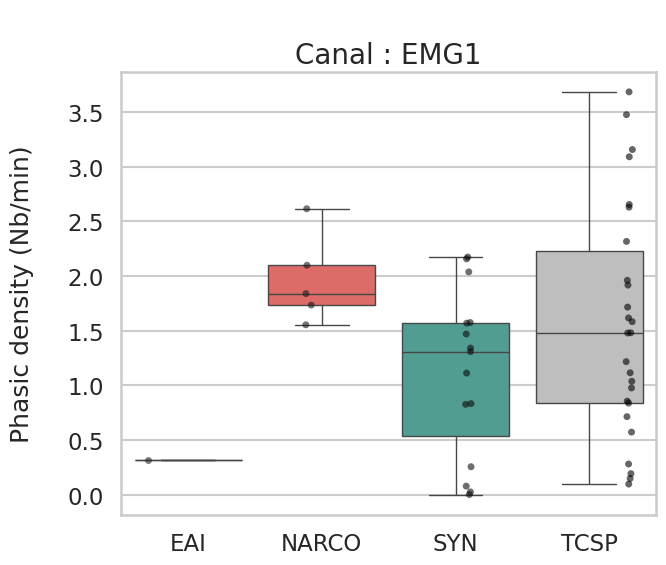

/tmp/ipykernel_220867/3682984918.py:39: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(


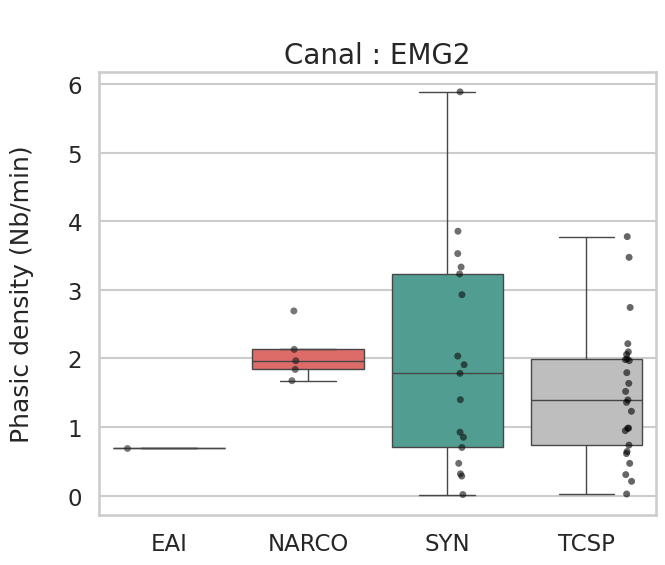

/tmp/ipykernel_220867/3682984918.py:39: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(


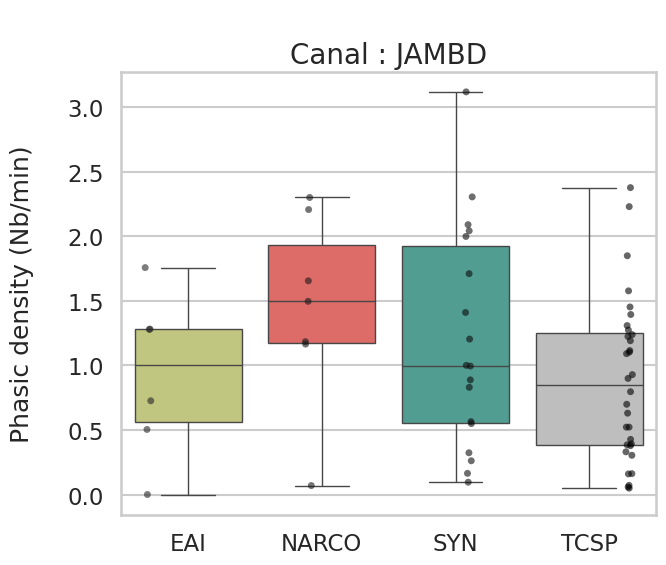

/tmp/ipykernel_220867/3682984918.py:39: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(


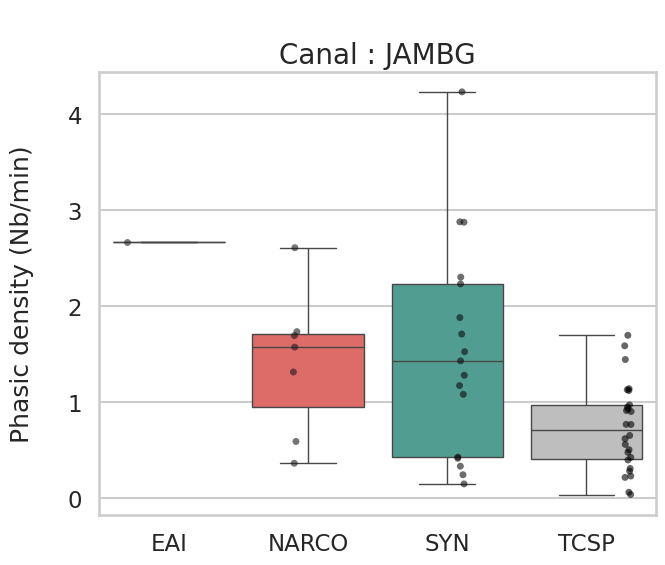

/tmp/ipykernel_220867/3682984918.py:39: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(


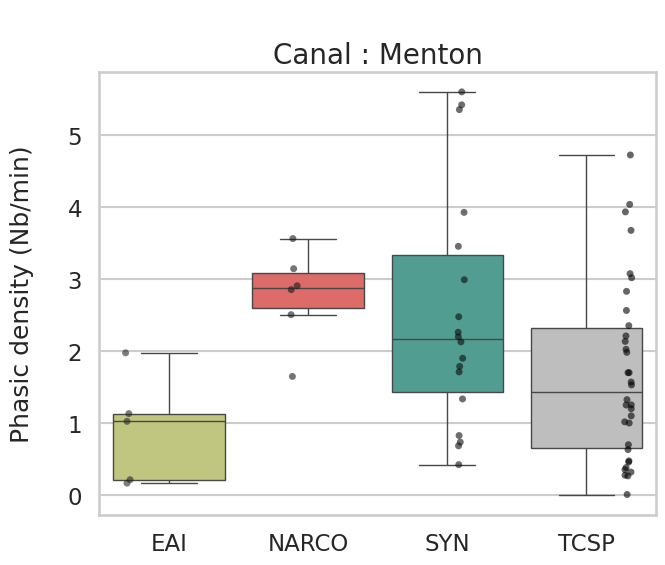

In [80]:
for ch in summary_patient["channel"].unique():
    plot_metric_by_channel(
        summary_patient,
        channel_name=ch,
        metric_col="mean_phasic_density",
        ylabel="Phasic density (Nb/min)\n",
        title=""
    )


## Figure 4) % REM phasic pendant le REM

/tmp/ipykernel_220867/3682984918.py:39: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(


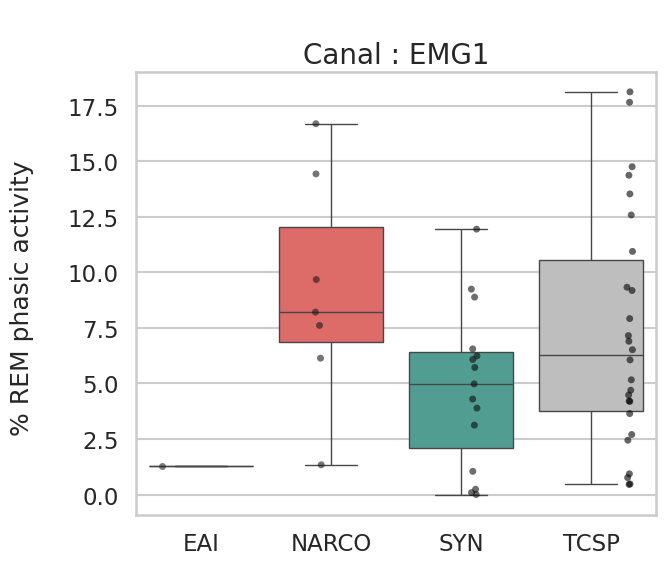

/tmp/ipykernel_220867/3682984918.py:39: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(


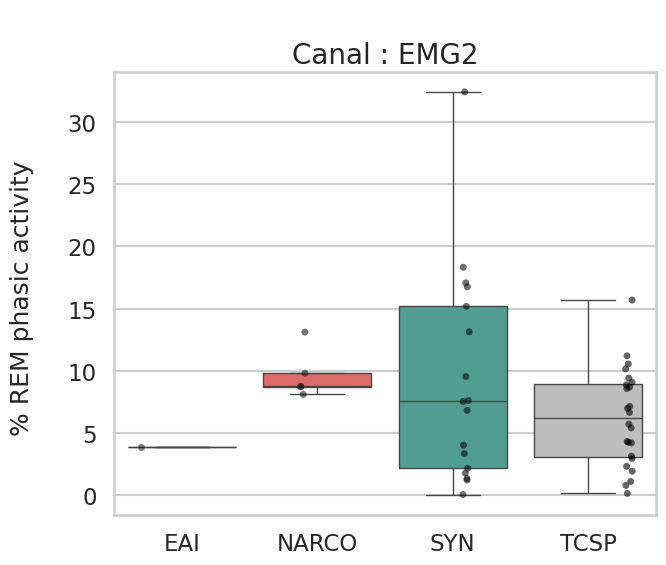

/tmp/ipykernel_220867/3682984918.py:39: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(


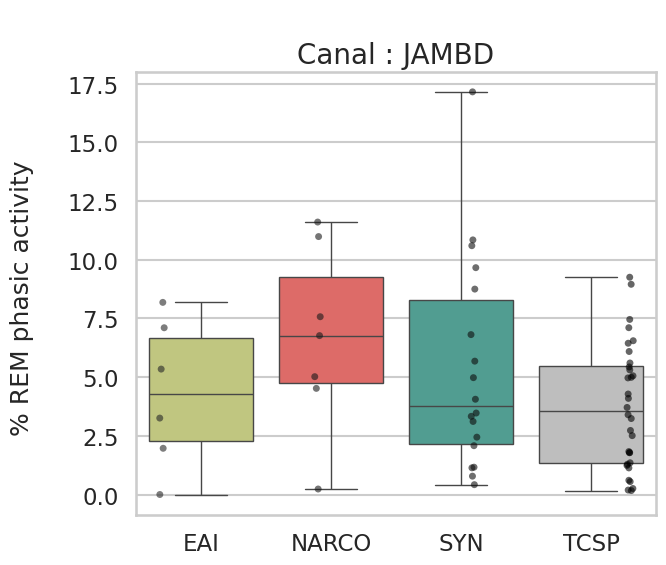

/tmp/ipykernel_220867/3682984918.py:39: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(


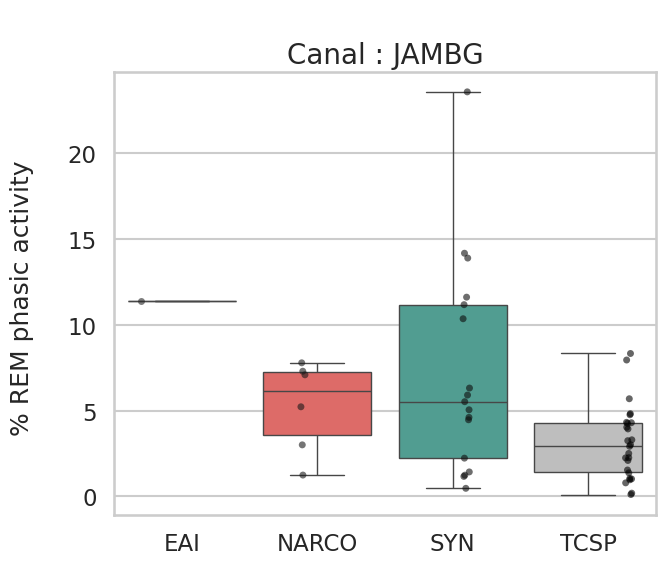

/tmp/ipykernel_220867/3682984918.py:39: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(


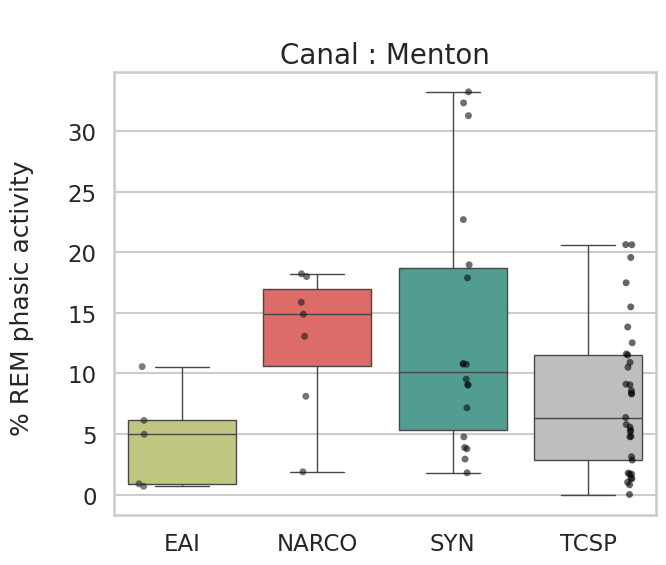

In [90]:
df_plot2 = summary_patient.copy()
df_plot2["mean_perc_phasic"] = df_plot["mean_perc_phasic"] * 100

for ch in df_plot2["channel"].unique():
    plot_metric_by_channel(
        df_plot2,
        channel_name=ch,
        metric_col="mean_perc_phasic",
        ylabel="% REM phasic activity \n",
        title=""
    )


## Figure 5 ) % REM très phasic

/tmp/ipykernel_220867/3682984918.py:39: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(


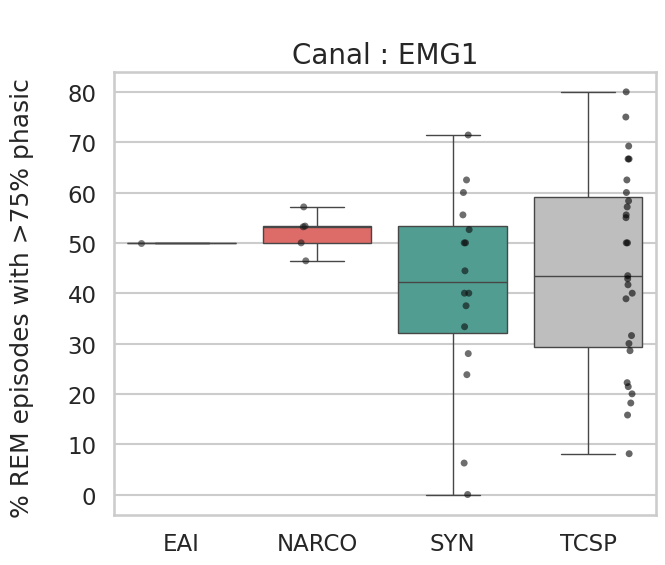

/tmp/ipykernel_220867/3682984918.py:39: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(


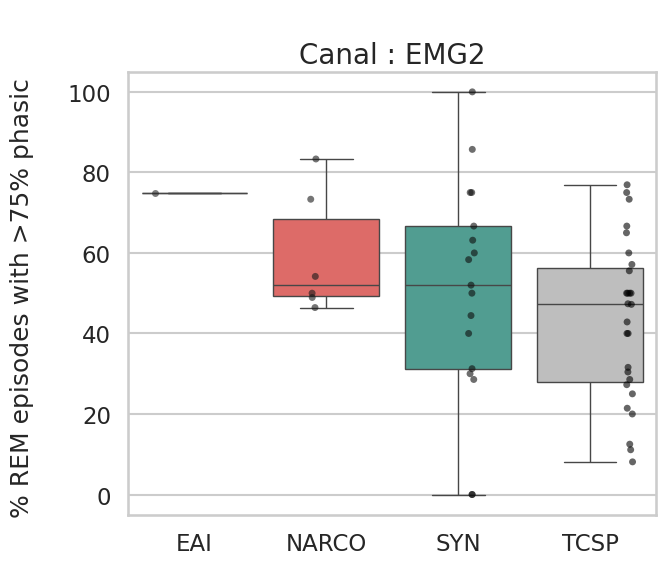

/tmp/ipykernel_220867/3682984918.py:39: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(


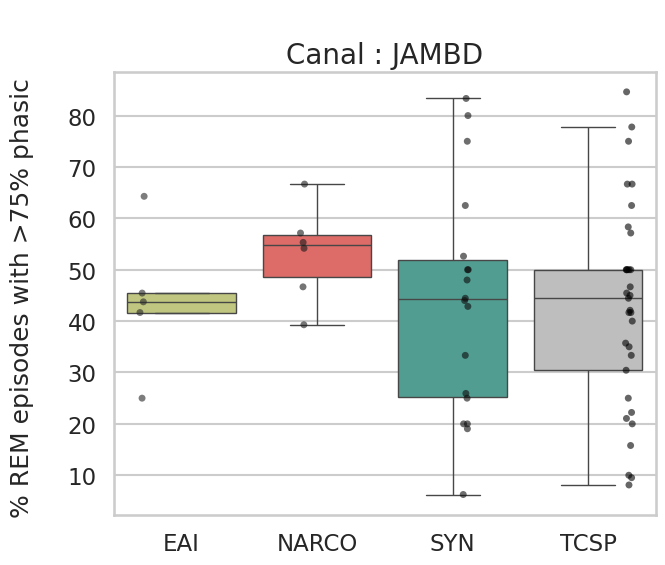

/tmp/ipykernel_220867/3682984918.py:39: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(


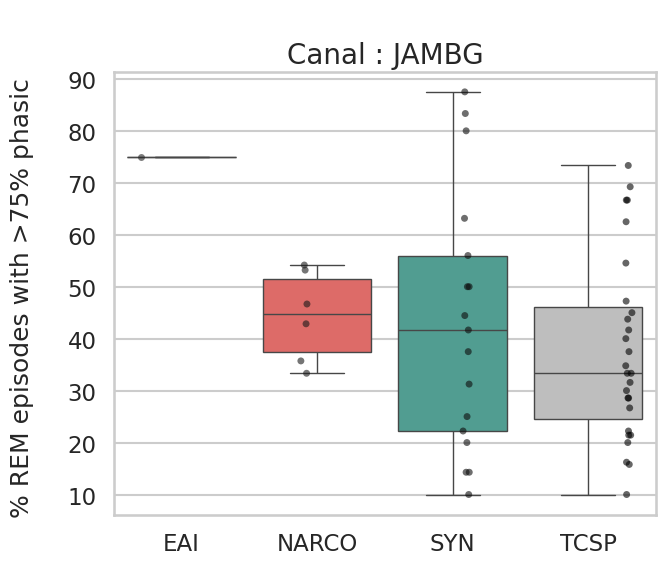

/tmp/ipykernel_220867/3682984918.py:39: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(


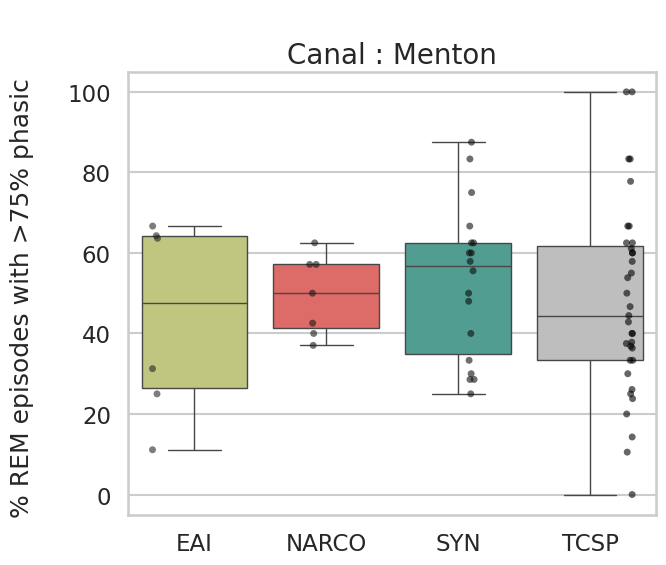

In [91]:
df_plot3 = summary_patient.copy()
df_plot3["pct_heavy"] = df_plot3["pct_heavy"] * 100

for ch in df_plot3["channel"].unique():
    plot_metric_by_channel(
        df_plot3,
        channel_name=ch,
        metric_col="pct_heavy",
        ylabel="% REM episodes with >75% phasic \n",
        title=""
    )


## Figure 6 ) Tonic ratio

/tmp/ipykernel_220867/3682984918.py:39: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(


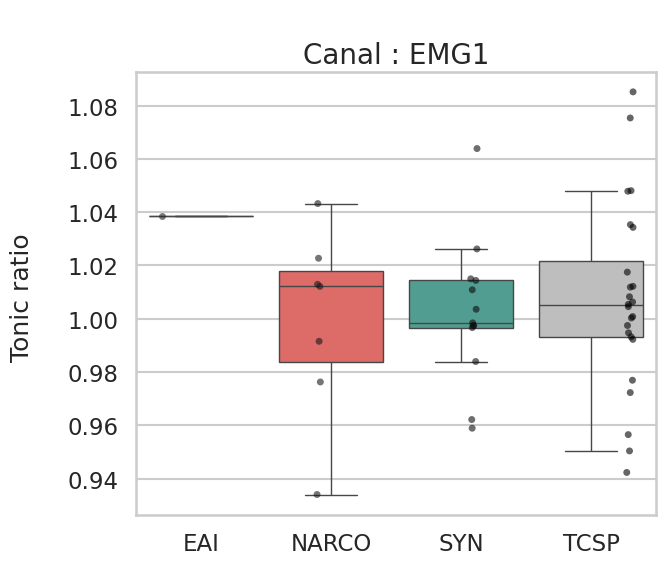

/tmp/ipykernel_220867/3682984918.py:39: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(


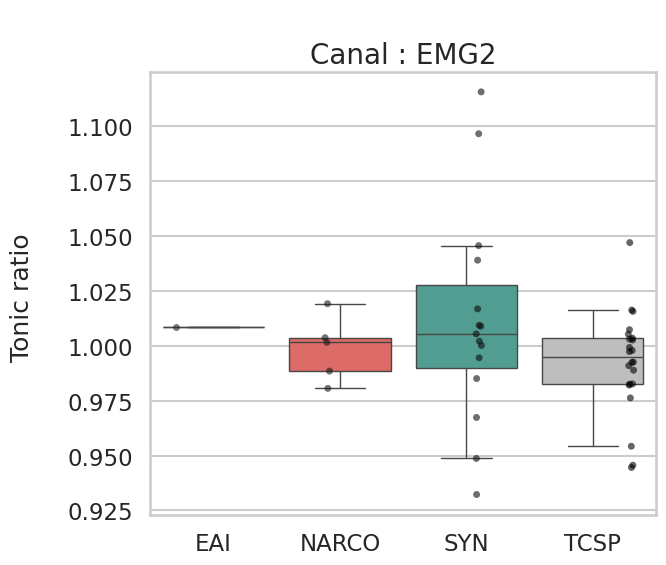

/tmp/ipykernel_220867/3682984918.py:39: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(


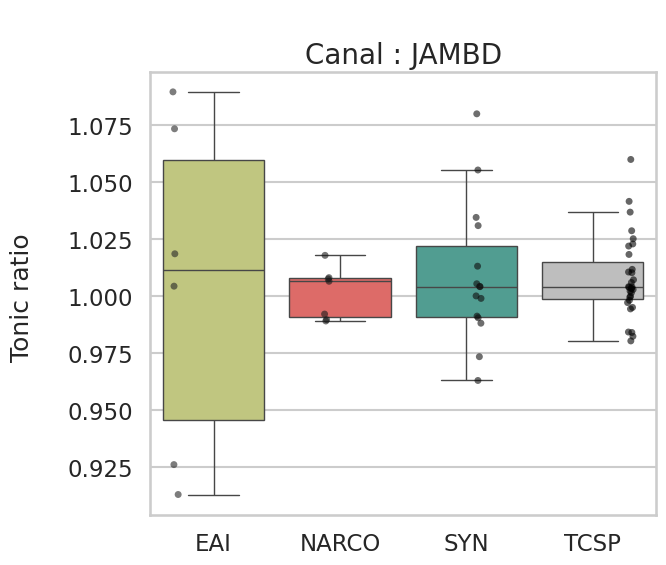

/tmp/ipykernel_220867/3682984918.py:39: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(


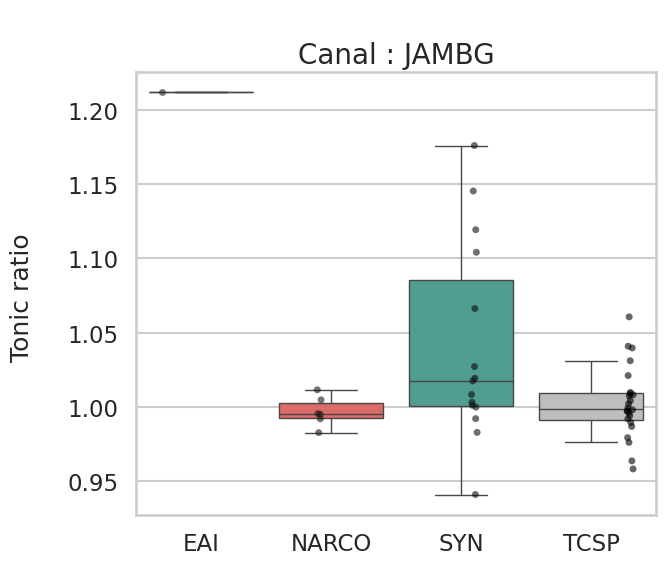

/tmp/ipykernel_220867/3682984918.py:39: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(


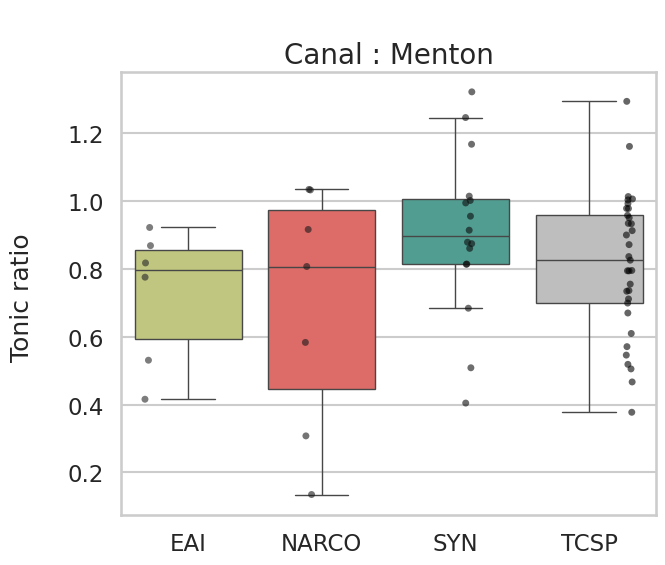

In [89]:
for ch in summary_patient["channel"].unique():
    plot_metric_by_channel(
        summary_patient,
        channel_name=ch,
        metric_col="median_tonic_ratio",
        ylabel="Tonic ratio \n",
        title=""
    )


## Figure 7 ) % RWSA

/tmp/ipykernel_220867/3682984918.py:39: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(


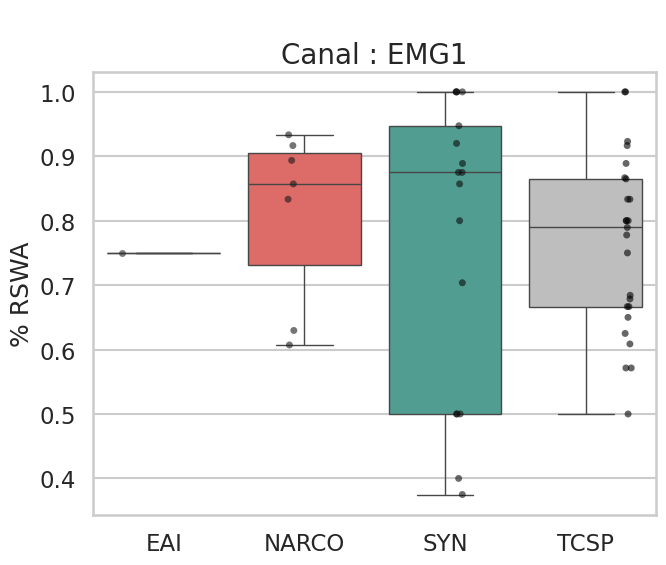

/tmp/ipykernel_220867/3682984918.py:39: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(


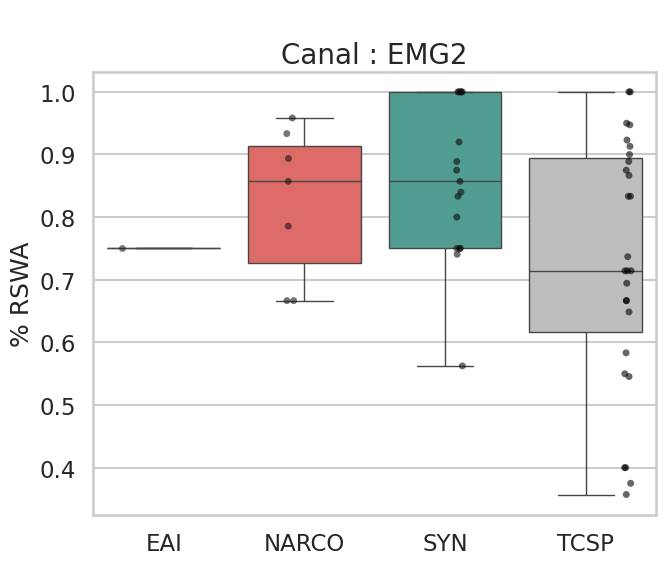

/tmp/ipykernel_220867/3682984918.py:39: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(


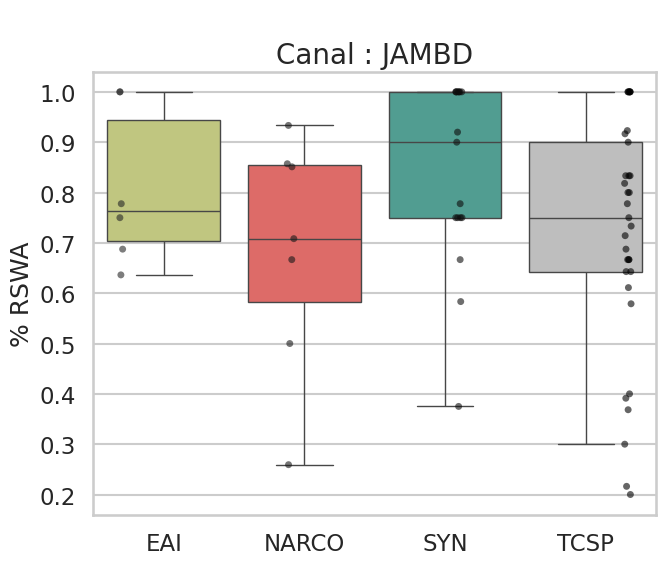

/tmp/ipykernel_220867/3682984918.py:39: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(


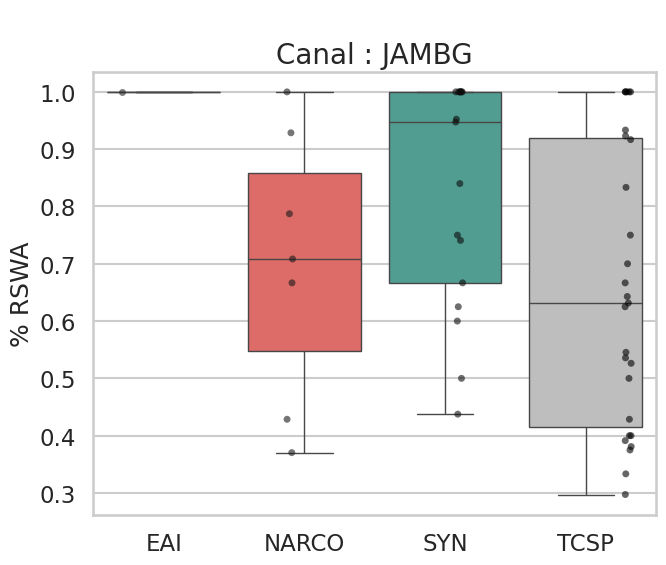

/tmp/ipykernel_220867/3682984918.py:39: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(


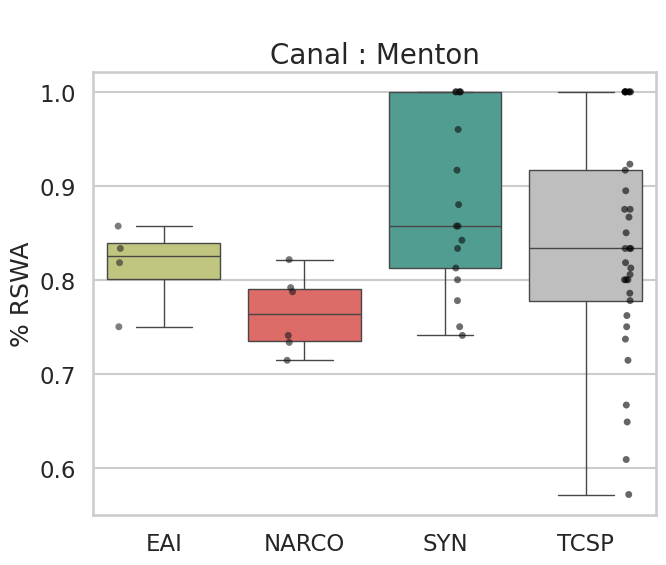

In [92]:
for ch in summary_patient["channel"].unique():
    plot_metric_by_channel(
        summary_patient,
        channel_name=ch,
        metric_col="pct_rswa",
        ylabel="% RSWA",
        title=""
    )


## ==========================
## Tests de significativité
Rappels : 
- Shapiro ==> Ho -> Anova + Tukey / H1 : Kruskall + Man WHitney 
- Bon ferroni
## ==========================

In [94]:
import pandas as pd
import numpy as np
from pathlib import Path

# Stats
import scipy.stats as st
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.stats.multitest import multipletests

# ======================= CONFIG =======================
# Dossier de sortie pour les CSV de résultats
OUTPUT_DIR       = "../outputs/stats/significativity" 
RUN_DIAGNOSTICS  = True                # Shapiro & Levene 
ALPHA            = 0.05

# Colonnes métriques (dans summary_patient)
METRIC_COLS = [
    "pct_ep_with_phasic",   # % REM avec ≥1 phasic
    "mean_phasic_density",  # densité phasique nb/min
    "mean_perc_phasic",     # % REM en phasic
    "pct_heavy",            # % épisodes très phasiques
    "median_tonic_ratio",   # ratio tonic REM/NREM
    "pct_rswa",             # % REM avec RSWA
]
# ======================================================

Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)

# On part de summary_patient déjà construit
df = summary_patient.copy()

# Passage en format "long" : une ligne = patient × group × channel × metric
long_df = df.melt(
    id_vars=["patient_id", "group", "channel"],
    value_vars=METRIC_COLS,
    var_name="metric",
    value_name="value"
).dropna(subset=["value"])

# --- Moyennes descriptives par metric × channel × group ---
means = (
    long_df
    .groupby(["metric", "channel", "group"], dropna=False)["value"]
    .agg(["mean", "std", "count"])
    .reset_index()
    .rename(columns={"mean": "group_mean", "std": "group_sd", "count": "n"})
)
means_path = Path(OUTPUT_DIR, "means_per_metric_per_channel_per_group.csv")
means.to_csv(means_path, index=False)

# ---------- Helpers ----------
def try_shapiro_by_group(d, group_col="group", y_col="value"):
    rows = []
    for g, sub in d.groupby(group_col):
        vals = sub[y_col].dropna().values
        if 3 <= len(vals) <= 5000:
            W, p = st.shapiro(vals)
            rows.append({"group": g, "n": len(vals), "W": W, "p_shapiro": p})
        else:
            rows.append({"group": g, "n": len(vals), "W": np.nan, "p_shapiro": np.nan})
    return pd.DataFrame(rows)

def try_levene(d, group_col="group", y_col="value"):
    groups = [sub[y_col].dropna().values for _, sub in d.groupby(group_col)]
    if any(len(g)==0 for g in groups) or len(groups) < 2:
        return np.nan, np.nan
    stat, p = st.levene(*groups, center='median')
    return stat, p

def run_anova(df, group_col="group", y_col="value"):
    d = df[[group_col, y_col]].dropna().copy()
    if d[group_col].nunique() < 2:
        return None
    model = ols(f"{y_col} ~ C({group_col})", data=d).fit()
    return anova_lm(model, typ=2)

def run_tukey(df, group_col="group", y_col="value"):
    d = df[[group_col, y_col]].dropna().copy()
    if d[group_col].nunique() < 2:
        return None
    return pairwise_tukeyhsd(d[y_col], d[group_col])

def tukey_to_dataframe(tuk, metric, ch):
    """
    Colonnes standardisées: metric, channel, group1, group2,
    meandiff, p_adj_tukey, lower, upper, reject
    """
    summ = tuk.summary()
    data = summ.data  # 1ère ligne = header
    df = pd.DataFrame(data[1:], columns=[c.strip() for c in data[0]])
    rename_map = {
        "group1": "group1",
        "group2": "group2",
        "meandiff": "meandiff",
        "p-adj": "p_adj_tukey",
        "lower": "lower",
        "upper": "upper",
        "reject": "reject",
    }
    df = df.rename(columns={k: v for k, v in rename_map.items() if k in df.columns})
    for col in ["meandiff", "p_adj_tukey", "lower", "upper"]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")
    if "reject" in df.columns:
        df["reject"] = df["reject"].astype(str).str.lower().isin(["true", "t", "1", "yes"])
    df.insert(0, "metric", metric)
    df.insert(1, "channel", ch)
    return df[["metric","channel","group1","group2","meandiff","p_adj_tukey","lower","upper","reject"]]

def run_kruskal(df, group_col="group", y_col="value"):
    d = df[[group_col, y_col]].dropna().copy()
    if d[group_col].nunique() < 2:
        return None
    groups = [vals[y_col].values for _, vals in d.groupby(group_col)]
    if any(len(g)==0 for g in groups):
        return None
    return st.kruskal(*groups)

def pairwise_mannwhitney_with_corrections(d, group_col="group", y_col="value"):
    from itertools import combinations
    rows = []
    guniq = sorted(d[group_col].dropna().unique())
    for g1, g2 in combinations(guniq, 2):
        x = d.loc[d[group_col]==g1, y_col].dropna().values
        y = d.loc[d[group_col]==g2, y_col].dropna().values
        if len(x) == 0 or len(y) == 0:
            continue
        u_stat, p_raw = st.mannwhitneyu(x, y, alternative="two-sided")
        nx, ny = len(x), len(y)
        r_rb = 1 - (2*u_stat)/(nx*ny)  # rank-biserial
        rows.append({
            "group1": g1,
            "group2": g2,
            "n1": nx,
            "n2": ny,
            "U": u_stat,
            "p_raw": p_raw,
            "r_rank_biserial": r_rb
        })
    res = pd.DataFrame(rows)
    if res.empty:
        return res
    for method in ["bonferroni", "holm"]:
        _, p_adj, _, _ = multipletests(res["p_raw"].values, method=method)
        res[f"p_{method}"] = p_adj
        res[f"sig_{method}"] = (p_adj < ALPHA)
    return res

# ---------- Boucle METRIC × CHANNEL ----------
anova_rows, kw_rows = [], []
tukey_rows, dunn_rows, diag_rows = [], [], []

for metric in sorted(long_df["metric"].dropna().unique()):
    df_m = long_df[long_df["metric"] == metric]
    for ch in sorted(df_m["channel"].dropna().unique()):
        df_mc = df_m[df_m["channel"] == ch][["group", "value"]].dropna().copy()
        if df_mc["group"].nunique() < 2:
            continue

        lev_stat = lev_p = np.nan
        if RUN_DIAGNOSTICS:
            sh = try_shapiro_by_group(df_mc)
            lev_stat, lev_p = try_levene(df_mc)
            sh["metric"] = metric
            sh["channel"] = ch
            diag_rows.append(sh)

        # ANOVA
        anova_tab = run_anova(df_mc)
        if anova_tab is not None and "C(group)" in anova_tab.index:
            F = anova_tab.loc["C(group)", "F"]
            p = anova_tab.loc["C(group)", "PR(>F)"]
            anova_rows.append({
                "metric": metric,
                "channel": ch,
                "F": F,
                "p_anova": p,
                "levene_stat": lev_stat,
                "levene_p": lev_p
            })
            # Tukey
            tuk = run_tukey(df_mc)
            if tuk is not None:
                tuk_df = tukey_to_dataframe(tuk, metric, ch)
                tukey_rows.append(tuk_df)

        # Kruskal–Wallis
        kw = run_kruskal(df_mc)
        if kw is not None:
            kw_rows.append({
                "metric": metric,
                "channel": ch,
                "H": kw.statistic,
                "p_kw": kw.pvalue
            })
            pw = pairwise_mannwhitney_with_corrections(df_mc)
            if not pw.empty:
                pw.insert(0, "metric", metric)
                pw.insert(1, "channel", ch)
                dunn_rows.append(pw)

# ---------- Concat & export ----------
anova_df = pd.DataFrame(anova_rows)
kw_df    = pd.DataFrame(kw_rows)

tukey_df = pd.concat(tukey_rows, ignore_index=True) if len(tukey_rows)>0 else pd.DataFrame(
    columns=["metric","channel","group1","group2","meandiff","p_adj_tukey","lower","upper","reject"]
)
dunn_df  = pd.concat(dunn_rows,  ignore_index=True) if len(dunn_rows)>0  else pd.DataFrame(
    columns=["metric","channel","group1","group2","n1","n2","U",
             "p_raw","r_rank_biserial","p_bonferroni","sig_bonferroni","p_holm","sig_holm"]
)
diag_df  = pd.concat(diag_rows,  ignore_index=True) if len(diag_rows)>0  else pd.DataFrame(
    columns=["metric","channel","group","n","W","p_shapiro"]
)

paths = {
    "means":  str(means_path),
    "anova":  str(Path(OUTPUT_DIR) / "anova_oneway_results.csv"),
    "tukey":  str(Path(OUTPUT_DIR) / "tukey_posthoc_results.csv"),
    "kw":     str(Path(OUTPUT_DIR) / "kruskal_results.csv"),
    "dunn":   str(Path(OUTPUT_DIR) / "dunn_pairwise_mannwhitney_results.csv"),
    "diag":   str(Path(OUTPUT_DIR) / "diagnostics_shapiro_levene.csv"),
}

anova_df.to_csv(paths["anova"], index=False)
kw_df.to_csv(paths["kw"], index=False)
tukey_df.to_csv(paths["tukey"], index=False)
dunn_df.to_csv(paths["dunn"], index=False)
diag_df.to_csv(paths["diag"], index=False)

print("=== Sorties CSV ===")
for k, v in paths.items():
    print(f"{k:>8}: {v}")

print("\n=== Résumé rapide ===")
def quick_sig(df, pcol, label):
    if df.empty or pcol not in df.columns:
        print(f"- {label}: aucun test")
        return
    sig = (df[pcol] < ALPHA).sum()
    tot = len(df)
    print(f"- {label}: {sig}/{tot} comparaisons significatives (p<{ALPHA})")

quick_sig(anova_df, "p_anova", "ANOVA")
quick_sig(kw_df,    "p_kw",    "Kruskal–Wallis")
if not tukey_df.empty:
    quick_sig(tukey_df, "p_adj_tukey", "Tukey (p ajustée)")
if not dunn_df.empty:
    quick_sig(dunn_df, "p_bonferroni", "Post-hoc MWU (Bonferroni)")
    quick_sig(dunn_df, "p_holm",       "Post-hoc MWU (Holm)")

# Les DataFrames restent disponibles:
# - means, anova_df, tukey_df, kw_df, dunn_df, diag_df


=== Sorties CSV ===
   means: ../outputs/stats/significativity/means_per_metric_per_channel_per_group.csv
   anova: ../outputs/stats/significativity/anova_oneway_results.csv
   tukey: ../outputs/stats/significativity/tukey_posthoc_results.csv
      kw: ../outputs/stats/significativity/kruskal_results.csv
    dunn: ../outputs/stats/significativity/dunn_pairwise_mannwhitney_results.csv
    diag: ../outputs/stats/significativity/diagnostics_shapiro_levene.csv

=== Résumé rapide ===
- ANOVA: 2/30 comparaisons significatives (p<0.05)
- Kruskal–Wallis: 2/30 comparaisons significatives (p<0.05)
- Tukey (p ajustée): 2/180 comparaisons significatives (p<0.05)
- Post-hoc MWU (Bonferroni): 1/180 comparaisons significatives (p<0.05)
- Post-hoc MWU (Holm): 1/180 comparaisons significatives (p<0.05)
